In [ ]:
# 목표: 경사 하강법 알고리즘을 이해하고 대량의 데이터에서 분류 모델을 훈련하는 방법 학습

In [ ]:
# 실무에선 train 데이터가 항상 '한번에' 준비되어 제공되지는 않는다. (거의 불가능)
# 일정량씩 혹은 불규칙하게 준비된다..

# 어떻게 할까?


In [ ]:
# 방법1
# 매일매일 새로이 추가된 데이터를 기존 데이터에 '더하여' 다시 훈련하자!

# 단점: 시간이 지날수록 데이터의 크기가 늘어나는데?
#    한번훈련시키기 위한 HW, 시간 소요...



In [ ]:
# 방법2
# 새로운 데이터 추가될때마다, 기존데이터버리고 새로운 데이터로만 학습하기
# 데이터 크기는 일정량 유지는 되겠지만...

# 단점: 버리는 데이터가 발생!  --> 중요한 데이터 포함안될수도 --> 제대로 예측못함.



# 점진적 학습
Incremental Learning

In [ ]:
# 점진적 학습이란!

# 기존의 훈련한 모델을 '버리지 않고'  새로운 데이터에 대해서만 '조금씩 더 훈련' 하는 방법!

#  => 이전 훈련에 사용했던 데이터를 모두 유지할 필요 없다
#  => 이전에 학습헸던 내용을 까먹지도 않을거다.

# 대표적인 점진적 학습 알고리즘 : SGD (Stochastic Gradient Descent) 확률적 경사 하강법


In [ ]:
# SGD를 사용하기 전에 이것이 어떤 알고리즘이고, 또 왜 중요한지에 대해 알아보자

# 확률적 경사 하강법
Stochastic Gradient Descent, SGD

In [ ]:
# Stochastic '확률적'  : '무작위하게', '랜덤하게' 의 표현
# Gradient   '경사'   : 언덕의 기울기
# Descent    '하강법'  : 경사를 따라 내려가는 방법

# 훈련세트 사용해서 내려가는 방향을 찾아야 하는데,  시작점은 '랜덤하게 시작' 된다. <- 확률적
# 훈련세트에서 '랜덤하게 하나 골라서 시작'  <- 확률적

# '내려가는 방향'으로 발걸음을 아주 '조금씩' 움직여야 한다


![](https://www.dropbox.com/scl/fi/53e9x8pqg157lfv1t2kmn/gradient_descent1.png?rlkey=ru38522jr5pdzunhnl6x58onp&st=fcjmo8y6&dl=1)

### 에포크 (epoch)

In [ ]:
# 랜덤하게 샘플에서 데이터 꺼내어 조금씩 내려온다
# 모든 훈련데이터를 다 사용하고 나서, 원하는 지점까지 내려오지 못했다면?
# 다시 모든 샘플을 처음부터 시작.

# 훈련세트를 한번 모두 사용하는 과정을 '에포크(epoch)' 라 한다


## Batch/Minibatch/Stochastic Gradient Descent

![](https://www.dropbox.com/scl/fi/69gacc1x9e12qrksf7018/batch01.png?rlkey=7ft8hhm4bjv96v9umxyb5ka87&st=t7kcixl4&dl=1)
![](https://www.dropbox.com/scl/fi/seoqtl5ruif4745e7rfz6/batch02.png?rlkey=unw3whliojq5cy8zy3so99ipp&st=ef8ecw48&dl=1)
![](https://www.dropbox.com/scl/fi/he3vvml1e3mvbv3rs5cgn/batch03.png?rlkey=206e57c4gs2a25t7a68oldvci&st=3avaubzt&dl=1)

In [ ]:
# ▶한번에 무작위로 '한개의 샘플'을 학습하여
# '한걸음씩' 움직여 내겨가는 것을 확률적 경사 하강법 (Stochastic Gradient Descent) 라 하고
# 중간에 튀는 데이터가 있으면 학습의 방향(기울기)이 엉뚱한 곳으로 내려갈수도 있는 위험성이 있습니다.

# ▶무작위로 '몇 개의 샘플'을 선택하여 학습한뒤
# 한걸음씩 경사를 내려가는 방식을 미니배치 경사 하강법 (minibatch gradient descent) 라 합니다
#  ↑ 실전에서 가장 많이 쓰이는 방식

# ▶극닥적으로 '전체 샘플'을 다 학습한뒤
# '한걸음씩' 경사를 내려가는 방식을 배치 경사 하강법 (Batch Gradient Descent) 라 합니다.
# 전체 데이터를 학습한뒤 움직이는 것이기에 가장 안정적인 방법이다.
# 그러나! 한번 움직이는데 전체 데이터를 사용하면 그만큼 HW  자원을 많이 사용하게 되고, HW 용량에 따라
# 한번에 전체 데이터를 모두 읽어오기 힘들수도 있다.


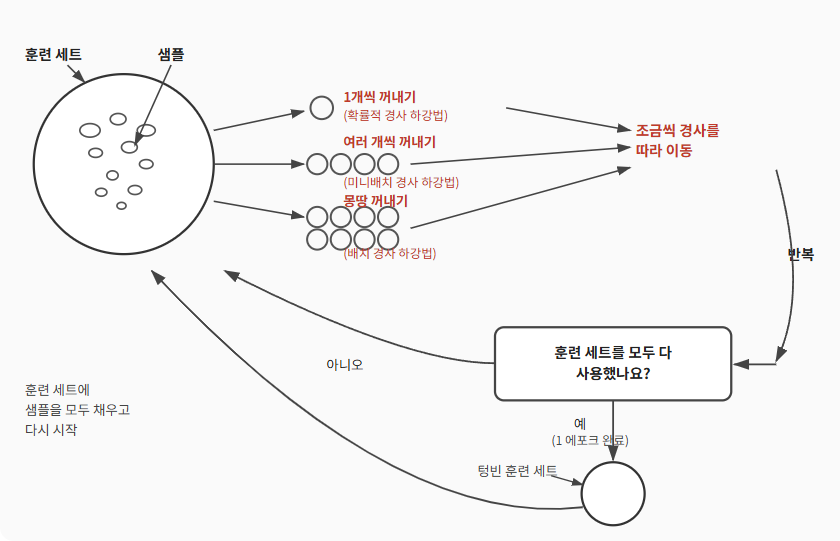

In [ ]:
# 확률적 경사 하강법을 사용하면
# '신규 데이터' 가 추가되어도 학습을 이어나갈수 있다.

# ★신경망 알고리즘은 '확률적 경사 하강법 ' 사용


In [ ]:
# 경사? 내려간다? 무엇이? --> '손실함수'

# 손실함수
loss function

학습한 모델이 예측한 값과 정답간의 '오차'를 측정하는 함수

얼마나 잘 맞추느냐 가 아니라 '**얼마나 잘 못 맞추는지**' 에 대한 값.

따라서 손실함수 값은 작으면 '**작을수록 좋은 것**'이다.

In [ ]:
# 우리가 다루는 많은 문제에 필요한 손실 함수는 이미 정의되어 있습니다.
# 생선을 분류하기 위해서는 어떤 손실함수를 사용하는지 알아보겠습니다.

In [ ]:
# 손실함수 (loss function)  : 샘플 하나에 대한 손실을 정의
# 비용함수 (cost function)  : 훈련세트에 있는 모든 샘플에 대한 손실함수값의 합
# ※ 그러나, 일반적으로 위 둘을 구분하지 않고 혼용하여 사용


## '분류'에서의 손실(loss)

In [ ]:
# '분류' 에서의 손실(loss)  => 정답을 못맞히는 겁니다.
# 예측     정답(target)
#  1   =    1
#  0   ≠    1
#  0   =    0
#  1   ≠    0

# 4개의 예측중 2개만 맞힘 -> '정확도' 0.5 -> 그렇다면, 이것을 손실함수로 사용할수 있나?


In [ ]:
# '정확도'를 손실함수로 사용 못하는 이유!
#
# 4개의 샘플만 있다면 정확도는 0, 0.25, 0.5, 0.75, 1 <= 5가지뿐!
# 그러나! 경사하강법은 '아주 조금씩' 내려와야 한다.

# 정확도가 '연속적' 이지 않으면 '조금씩 내려오기' 힘들다!
# 왜냐하면 손실함수는 '미분가능' 한 연속함수 형태여야 하기 때문이다!


![](https://www.dropbox.com/scl/fi/53e9x8pqg157lfv1t2kmn/gradient_descent1.png?rlkey=ru38522jr5pdzunhnl6x58onp&st=9n3infd6&dl=1)

## 로지스틱 손실 함수 (이진분류)
logistic loss function

aka. binary cross-entropy loss function (BCE)

## 크로스엔트로피 손실함수 (다중분류)
cross-entropy loss function

다중분류 문제 에서의 손실함수

## MSE, MAE (회귀문제)

In [ ]:
# '회귀' 는 어떤 손실함수를 사용하나?

# 회귀 문제의 경우  '평균 절대값 오차(Mean absolute error, MAE)' 를 사용할수 있습니다.
# target 에서 예측을 뺀 절대값을 모든 샘플에 평균한 값.

# 혹은 '평균 제곱 오차 (mean squared error, MSE)' 를 많이 사용함.
# target 에서 예측을 뺀 값을 제곱한 다음 모든 샘플에 대한 평균한 값.  <- 이 값이 작을수록 좋은 모델!


In [ ]:
# 손실함수를 우리가 직접 만드는 일은 거의 없습니다.
# 이미 손실함수들은 정의되어 제공되기 때문입니다.

# SGDClassifier

### 데이터 준비

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
base_path = r'/content/drive/MyDrive/KoreaIT (코리아it)/260113 💚AI MCP 에이전트 S1/[MCP_Agent]/dataset(MCP2601)'

In [3]:
file_path = os.path.join(base_path, 'fish.csv')

fish_df = pd.read_csv(file_path)

fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [4]:
# 입력데이터와 타겟데이터 분리

fish_input = fish_df[['Weight','Length','Diagonal','Height','Width']].to_numpy()
fish_target = fish_df['Species'].to_numpy()

In [5]:
# 훈련 / 테스트 세트 나누기
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

print(train_input.shape, test_input.shape)

(119, 5) (40, 5)


In [6]:
# 전처리 (표준화)
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

###  모델 학습 (epoch)

In [7]:
# 사이킷런에서 확률적경사하강법을 제공하는 대표적인 분류용 클래스 SGDClassifier
from sklearn.linear_model import SGDClassifier

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html
```python
class sklearn.linear_model.SGDClassifier(
  loss='hinge',  # 손실함수 종류
  *,
  penalty='l2',
  alpha=0.0001,
  l1_ratio=0.15,
  fit_intercept=True,
  max_iter=1000,  # 수행할 epoch 횟수
  tol=0.001, # 일정 epoch 동안 성능이 향상되지 않으면 자동으로 멈춤 , None 으로 지정하면 자동으로 멈추지 않음
  shuffle=True,
  verbose=0,
  epsilon=0.1,
  n_jobs=None,
  random_state=None,
  learning_rate='optimal',
  eta0=0.0,
  power_t=0.5,
  early_stopping=False,
  validation_fraction=0.1,
  n_iter_no_change=5,
  class_weight=None,
  warm_start=False,
  average=False)
```

In [ ]:
# SGDClassifier 객체를 만들 때 2개의 매개변수를 지정
#  loss=  손실함수 종류   'log_loss' - 로지스틱 손실함수
#  max_iter=  수행할 epoch 횟수.

In [8]:
# ※ 사이킷런 1.1.0 버전 이하일 경우 'log_loss'를 'log'로 바꾸어 주세요.
sc = SGDClassifier(
    loss='log_loss',
    max_iter=10,    # 최대 epoch 횟수
    random_state=42,
)

sc.fit(train_scaled, train_target) # 훈련

print(sc.score(train_scaled, train_target))  # train 세트 점수
print(sc.score(test_scaled, test_target))    # test 세트 점수

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
# ↑ 훈련세트, 테스트세트 에서의 점수가 모두 낮다.
# max_iter=10 이 부족하다 => ConvergenceWarning 경고


## 점진적학습 partial_fit()

In [ ]:
# 확률적 경사 하강법은 '점진적 학습' 가능
# 모델을 다시 만들지 않고도,  이미 훈련된 모델에 추가로 훈련이 가능하다

# 사이킷럿에서 모델을 추가로 이어서 훈련 => partial_fit() 사용
#  fit() 과 사용법은 같으나, 호출할때마다 1 epoch 씩 이어서 훈련한다


In [10]:
# partial_fit() 을 호출하고 다시 점수 확인해보자

sc.partial_fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7815126050420168
0.8


In [ ]:
# 에포크 를 한번더 실행하니 -> 정확도 향상.
# 얼마다 더 훈련하면 좋을까?


In [ ]:
# 비록 학습에 모든 훈련세트 데이터를 전달했지만,
# SGDClassifier 는 전달받은 훈련세트에서 '1개씩' 샘플을 꺼내어 경사 하강법 수행.
# SGDClassifier 는 '미니배치 / 배치 경사하강법' 제공 안함


# 에포크의 과대 / 과소적합

In [ ]:
# '너무 적은 에포크 ' -> 훈련세트 와 테스트세트에 모두 잘 맞지 않는 underfit 가능성 높다
# '너무 많은 에포크 ' -> 훈련세트에 너무 잘맞고 테스트세트에는 오히려 점수 나쁜 overfit 가능성 높다


![](https://www.dropbox.com/scl/fi/lza8ugfo8gbtmtf495m8r/epoch_accuracy.png?rlkey=filnyfk6ocsy0r1639f9bee3b&st=u6vcgkb6&dl=1)

In [ ]:
# 훈련 세트 점수는 에포크가 진행될수록 꾸준히 증가하지만 테스트 세트 점수는 어느 순간 감소하기 시작합니다.
# 바로 이 지점이 모델이 과대 적합되기 시작하는 곳입니다.
# 과대 적합이 시작하기 전에 훈련을 멈추는 것을 조기 종료 (early stopping) 이라 합니다.


In [11]:
# ※사이킷런 1.1 버전에서는 SGDClassifier의 loss 매개변수 중
#   로지스틱 손실을 의미하는 'log'가 'log_loss'로 바뀐다는 경고가 발생합니다.
#   사이킷런 1.1 이상을 사용하는 경우 loss='log'를 loss='log_loss'로 변경하세요.

sc = SGDClassifier(loss='log_loss', random_state=42)


In [12]:
# classes
classes = np.unique(train_target)
classes


array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [13]:
# 300번의 에포크 수행 => 훈련세트와 테스트세트 점수 기록

train_score = []
test_score = []

for _ in range(0, 300):
    sc.partial_fit(train_scaled, train_target, classes=classes)

    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

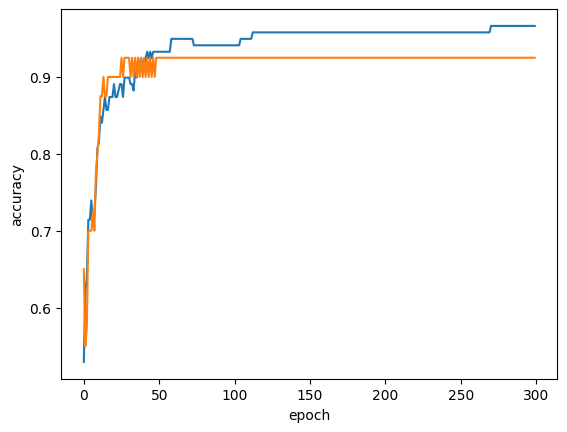

In [14]:
# 300번 의 에포크 동안 기록한 훈련세트와 테스트 세트의 점수를 시각화

plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [15]:
# SGDClassifier 의 반복 횟수(max_iter)를 100에 맞추고 모델을 다시 훈련하고 점수 확인해보자

# SGDClassifier 는 일정 에포크 동안 성능이 향상되지 않으면 더 훈련하지 않고 자동으로 멈춥니다.
# tol= 매개변수는 향상될 최솟값을 지정합니다. (tolerence)  (기본값 0.001)
#     None 으로 지정하면 자동으로 멈추지 않고 max_iter 만큼 무조건 반복합니다

sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [16]:
# 힌지 손실함수를 사용하여 같은 반복 횟수동안 모델을 훈련해보겠습니다.
sc = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)

print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925


# 점진적 학습을 위한 확률적 경사 하강법  (정리)

- 오늘날 대량의 데이터를 한꺼번에 HW 메모리에 로딩할수 없기에
   데이터를 조금씩 사용해 점진적으로 학습하는 방법이 필요해졌다
   **확률적경사 하강법**이 그 방법중 하나다!

- 확률적경사 하강법을 사용하여 학습하는 로지스틱회귀 모델을 훈련했다
- 확률적경사 하강법은 '**손실함수**' 를 사용하여 손실함수 값이 낮아지는 방향으로 조금씩 내려오는 알고리즘
- 충분히 반복하여 훈련하면 훈련세트에서 높은 점수를 얻는 모델을 만들수 있다.
- 훈련이 반복되면 어느 순간 **과대적합**이 될수 있고 정확도가 오히려 떨어질수도 있다
